# UTS Data Science - Dokumentasi Praktikum
## Pertemuan 4: Statistika Dasar & Analisis Data

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Langkah 1 & 2: Load Dataset & Ringkasan Statistik Deskriptif Lengkap
Kita akan memuat dataset Iris langsung melalui pustaka Seaborn dan menghitung nilai pemusatan data (mean, median, modus) serta penyebaran data (standar deviasi, varians, skewness, dan kurtosis) untuk setiap fitur numerik.

In [1]:
# Mengimpor semua pustaka yang dibutuhkan sesuai dengan modul praktikum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Langkah 1: Memuat dataset Iris bawaan seaborn
df = sns.load_dataset('iris')

# Menampilkan informasi dasar dimensi dan tipe data
print(f"Dimensi Dataset : {df.shape}")
print(f"Daftar Kolom    : {df.columns.tolist()}\n")

# Langkah 2: Menghitung statistik deskriptif lengkap per kolom numerik
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f"=== Analisis Statistik Kolom: {col_name} ===")
    print(f"Mean (Rata-rata)   : {col.mean():.3f}")
    print(f"Median (Nilai Tengah): {col.median():.3f}")
    print(f"Modus              : {col.mode()[0]:.3f}")
    print(f"Standar Deviasi    : {col.std():.3f}")
    print(f"Varians            : {col.var():.3f}")
    print(f"Skewness (Asimetri): {col.skew():.3f}")
    print(f"Kurtosis (Ekor)    : {col.kurt():.3f}")
    print("-" * 40 + "\n")

Dimensi Dataset : (150, 5)
Daftar Kolom    : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

=== Analisis Statistik Kolom: sepal_length ===
Mean (Rata-rata)   : 5.843
Median (Nilai Tengah): 5.800
Modus              : 5.000
Standar Deviasi    : 0.828
Varians            : 0.686
Skewness (Asimetri): 0.315
Kurtosis (Ekor)    : -0.552
----------------------------------------

=== Analisis Statistik Kolom: sepal_width ===
Mean (Rata-rata)   : 3.057
Median (Nilai Tengah): 3.000
Modus              : 3.000
Standar Deviasi    : 0.436
Varians            : 0.190
Skewness (Asimetri): 0.319
Kurtosis (Ekor)    : 0.228
----------------------------------------

=== Analisis Statistik Kolom: petal_length ===
Mean (Rata-rata)   : 3.758
Median (Nilai Tengah): 4.350
Modus              : 1.400
Standar Deviasi    : 1.765
Varians            : 3.116
Skewness (Asimetri): -0.275
Kurtosis (Ekor)    : -1.402
----------------------------------------

=== Analisis Statistik Kolom: petal_wi

**Analisis Temuan Langkah 1 & 2:**
Dataset Iris ini memiliki total 150 baris data dengan 5 variabel utama. Berdasarkan perhitungan statistik, kolom `sepal_length` dan `sepal_width` memiliki nilai mean dan median yang sangat berdekatan, serta nilai skewness yang berada di rentang -0.5 hingga 0.5. Hal ini menandakan bahwa distribusi kedua variabel tersebut cenderung simetris atau mendekati sebaran normal.

## Langkah 3 & 4: Analisis Distribusi Univariat (Histogram, KDE, dan Boxplot)
Pada tahap ini, kita akan melihat sebaran data secara visual. Kita akan memplot kurva distribusi variabel `sepal_length` serta membandingkan variasi ukuran variabel `petal_length` antar-spesies menggunakan diagram Boxplot dan Violin Plot.

/tmp/ipykernel_988/298318396.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[1])


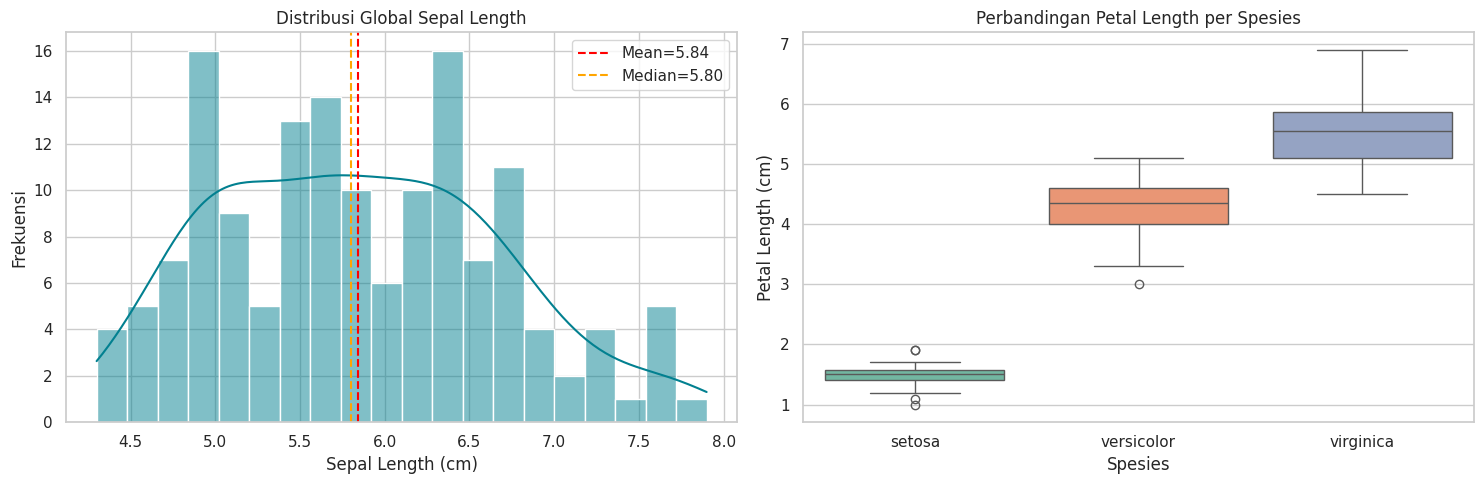

/tmp/ipykernel_988/298318396.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='sepal_length', palette='Set2', inner='box')


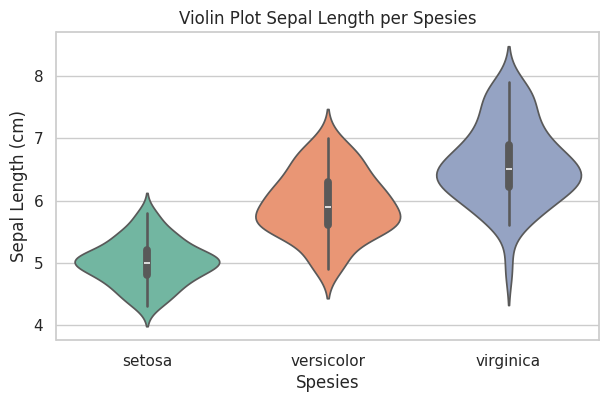

In [2]:
# Set tata letak grafis menggunakan Seaborn style
sns.set_theme(style="whitegrid")

# Langkah 3: Membuat Histogram + kurva KDE untuk Sepal Length
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=axes[0])
axes[0].axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
axes[0].axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
axes[0].set_title('Distribusi Global Sepal Length')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Langkah 4: Membuat Boxplot Petal Length per Spesies bunga
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[1])
axes[1].set_title('Perbandingan Petal Length per Spesies')
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

# Menampilkan grafik Violin Plot tambahan untuk melihat kepadatan data secara utuh
plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='species', y='sepal_length', palette='Set2', inner='box')
plt.title('Violin Plot Sepal Length per Spesies')
plt.xlabel('Spesies')
plt.ylabel('Sepal Length (cm)')
plt.show()

**Analisis Temuan Langkah 3 & 4:**
* Lewat grafik histogram, garis merah (mean) dan garis oranye (median) pada variabel `sepal_length` berimpit di area ukuran 5.8 cm, mempertegas bukti bahwa sebaran datanya berdistribusi normal.
* Melalui perbandingan diagram Boxplot, terlihat sebaran kelompok yang sangat kontras. Spesies **Iris Setosa** memiliki ukuran kelopak bunga (`petal_length`) terkecil dan terpusat di bawah 2 cm. Sebaliknya, spesies **Iris Virginica** memiliki ukuran kelopak paling besar dan variasi sebarannya paling lebar (paling beragam) dibandingkan kedua spesies lainnya.

## Langkah 5 & 6: Analisis Korelasi Bivariat (Pearson Matriks & Heatmap)
Sekarang kita beralih ke analisis hubungan antar dua variabel. Kita akan menghitung keeratan hubungan linear menggunakan koefisien korelasi Pearson dan menyajikannya lewat peta warna (Heatmap) serta diagram pencar (Scatter Plot).

=== MATRIKS KORELASI PEARSON ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Hasil deteksi otomatis:
Hubungan linear terkuat ada pada pasangan: ('petal_width', 'petal_length') dengan nilai r = 0.963


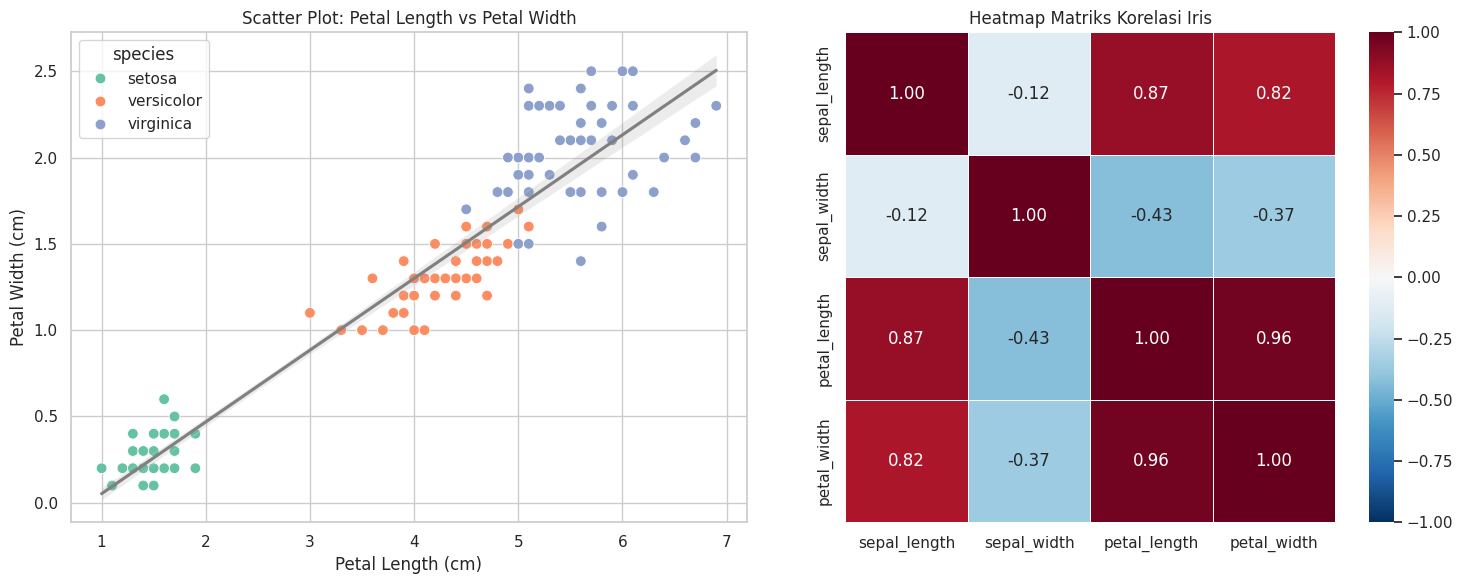

In [3]:
# Langkah 5: Menghitung matriks korelasi Pearson untuk kolom numerik (membuang kolom spesies)
matriks_korelasi = df.drop('species', axis=1).corr(method='pearson')
print("=== MATRIKS KORELASI PEARSON ===")
print(matriks_korelasi.round(3))

# Mencari otomatis pasangan variabel dengan tingkat hubungan tertinggi
mask = np.triu(np.ones(matriks_korelasi.shape, dtype=bool))
korelasi_terpilih = matriks_korelasi.where(~mask)
pasangan_tertinggi = korelasi_terpilih.stack().idxmax()
nilai_tertinggi = korelasi_terpilih.stack().max()

print(f"\nHasil deteksi otomatis:")
print(f"Hubungan linear terkuat ada pada pasangan: {pasangan_tertinggi} dengan nilai r = {nilai_tertinggi:.3f}")

# Langkah 6: Visualisasi Scatter Plot pasangan terkuat + Heatmap interaktif
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Hubungan Dua Variabel Terkuat
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', s=60, ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Plot Peta Warna (Heatmap) Korelasi
sns.heatmap(matriks_korelasi, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Heatmap Matriks Korelasi Iris')

plt.tight_layout()
plt.show()

**Analisis Temuan Langkah 5 & 6:**
Berdasarkan visualisasi grafik bivariat, kita menemukan hubungan yang sangat kuat antara kolom `petal_length` dengan `petal_width` yang dibuktikan dengan nilai koefisien Pearson setinggi **0.96**. Grafik scatter plot menampilkan arah tren yang naik lurus ke kanan atas (korelasi positif kuat). Artinya, semakin panjang mahkota bunga Iris, maka ukurannya dipastikan akan semakin melebar pula. Tren garis regresi abu-abu ini berlaku selaras untuk seluruh sub-populasi spesies bunga Iris.

## Kesimpulan & Refleksi Pembelajaran (Sesi 4)

### 1. Apa yang Dipelajari?
Pada pertemuan keempat ini, saya mempelajari konsep dasar statistika deskriptif untuk menguji pemusatan dan penyebaran data menggunakan instrumen Python. Saya mempraktikkan proses analisis univariat untuk membedakan tipe bentuk sebaran data (apakah berdistribusi normal simetris atau miring/skewed) serta melakukan analisis bivariat guna mendeteksi keeratan hubungan antar-variabel menggunakan koefisien Pearson, grafik scatter plot, dan visualisasi visual matriks korelasi menggunakan heatmap warna.

### 2. Temuan Utama
* Analisis statistik deskriptif tidak boleh bertumpu pada nilai rata-rata (mean) saja karena sifatnya yang sangat rapuh dan sensitif terhadap gangguan data pencilan. Kita harus selalu mengecek nilai median sebagai pembanding yang kuat.
* Ukuran mahkota bunga (`petal_length` dan `petal_width`) memiliki nilai korelasi positif linear yang hampir sempurna (r = 0.96). Fitur ini merupakan variabel pembeda paling potensial untuk memisahkan jenis kelompok spesies bunga Iris secara akurat dalam proses pemodelan klasifikasi ke depannya.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Uji korelasi Pearson yang dilakukan di praktikum ini memiliki asumsi bahwa hubungan antar-variabel harus bersifat linear lurus dan berdistribusi normal. Model ini tidak dapat membaca hubungan yang polanya melengkung atau non-linear.
* **Pertanyaan:** Jika di dalam proyek data riil kita dihadapkan pada variabel bertipe data campuran ordinal (bertingkat) atau distribusinya miring ekstrem, bagaimana cara yang tepat untuk memilih antara penggunaan metode korelasi Pearson atau korelasi Spearman?